## Групповой проект №4. Statistics in Data Analysis


#### Часть 1. A/B-тест

Для выполнения первой части группового проекта вам предоставляется датасет с результатами проведения некоторого A/B-тестирования в компании из сферы образования.


Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).








По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.

Вам следует:
- понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;
- проверить корректность проведения тестирования (посмотреть на однородность групп; задуматься об A/A-тесте; не забыть, что в нашем распоряжении есть еще и временные метки);
- сформулировать нулевую и альтернативную гипотезы на основании выбранной метрики;
- выбрать и обосновать статистический тест;
- решить, нужно ли устаналивать значения каких-либо параметров до начала анализа тестирования;
- оценить разницу в результатах и сделать выводы о практической значимости эксперимента;
- провести дополнительный анализ при необходимости (например, с помощью [bootstrap](https://habr.com/ru/companies/X5Tech/articles/679842/)  или через анализ чувствительности);
- сформулировать рекомендации и бизнес-инсайты по результатам эксперимента.

**Важно**: это лишь возможные шаги для вашего исследования, и воспринимать их следует как подсказки. Ваша центральная задача в любом случае представлена в общем виде — осуществить качественный и полный анализ результатов проведенного A/B-тестирования.



### Полезные замечания и советы

- Графики и визуализации помогают наглядно доносить информацию, а также анализировать данные
- Формулируйте гипотезы *после* EDA. Не придумывайте гипотезы "вслепую", сначала погрузитесь в данные, найдите закономерности, паттерны и лишь затем переходите к выделению статически проверяемых гипотез
- Не забывайте о прикладной значимости ваших проектов — ваш анализ должен быть полезен потенциальному заказчику
- Используйте разные подходы к проверке гипотез. Ищите способы усилить ваши тесты. Применяйте новые методы и идеи, а затем рассказывайте про них нам. Не бойтесь экспериментировать! Это будет только поощряться :)


### Критерий 1. Анализ результатов A/B-тестирования (до 3,5 баллов)

Данный критерий оценивает качество, глубину и корректность проведенного анализа результатов A/B-тестирования, включая выбор метрики, оценку реализации теста, а также спектр статистических методов и их обоснованность, формулирование гипотез и выводов по проделанному исследованию.

*По данному критерию можно получить **1 балл и выше** только при условии осмысленного осуществления этапа EDA, корректного выбора метрики, верной формулировки гипотез, обоснованного проведения статистического теста и правильной интерпретации полученных результатов.*

*По данному критерию можно получить **2 балла и выше** только при условии учёта в значительной степени временной составляющей эксперимента.*

*По данному критерию можно получить **3 балла и выше** только при условии обоснованного применения дополнительных инструментов/подходов для анализа результатов A/B-тестирования, не упомянутых ранее в этом ноутбуке и не рассматривавшихся в рамках соответствующего семинара и лекции (bootstrap'a или анализа чувствительности может хватить на 3 балла при условии корректного и осмысленного их применения).*




Запустим необходимые библиотеки

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

Скачаем наш датасет и посмотрим, как он выглядит

In [ ]:
df = pd.read_csv('data_ab.csv')
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


Проверим, что наши выборки однородны

In [ ]:
df[df['group'] == 'control'].shape[0], df[df['group'] != 'control'].shape[0]

(147202, 147276)

In [ ]:
(df[df['group'] != 'control'].shape[0] - df[df['group'] == 'control'].shape[0]) / df[df['group'] == 'control'].shape[0] * 100

0.050271056099781254

In [ ]:
chi2, p_value = chisquare(f_obs=df['group'].value_counts(),
                          f_exp=[df['group'].value_counts().sum() / 2, df['group'].value_counts().sum() / 2])

print(f"P-value = {p_value:.6f}")

P-value = 0.891532


Различие в размерах выборок 0.05%, различия статистически не значимы

Заметим, что некоторые пользователи упоминаются в датасете более одного раза

In [ ]:
df[df.duplicated('user_id', keep=False)].sort_values('timestamp')

,user_id,timestamp,group,landing_page,converted
148522,899221,2025-01-02 13:51:03.430500,control,old_page,0
155490,693254,2025-01-02 13:54:54.484142,control,old_page,0
291728,828985,2025-01-02 13:55:08.790046,control,new_page,0
282585,704123,2025-01-02 14:02:37.398357,control,old_page,0
167601,787103,2025-01-02 14:03:33.543019,control,new_page,0
...,...,...,...,...,...
228167,670745,2025-01-24 13:25:28.589447,control,new_page,0
267468,716469,2025-01-24 13:33:31.884168,control,old_page,1
61172,836114,2025-01-24 13:35:29.953109,treatment,new_page,0
125006,759292,2025-01-24 13:38:33.534130,control,old_page,0


Посмотрим, как распределены данные по выборкам. Заметим, что что-то работает не так, как нужно, датасет распределет в рамках одной группы (тестовой и контрольной) по разным страницам, что некорректно в рамках A/B теста

In [ ]:
df.groupby(['group', 'landing_page', 'converted']).size()

group      landing_page  converted
control    new_page      0              1694
                         1               234
           old_page      0            127785
                         1             17489
treatment  new_page      0            128047
                         1             17264
           old_page      0              1715
                         1               250
dtype: int64

Проверяем, что если пользователь появляется в датасете больше одного раза, то он появляется только 2 раза. В дальнейшем мы можем брать только первое взаимодействие с сайтом (так как на второе взаимодействие влияет первое)

In [ ]:
df.groupby('user_id').size().sort_values()

,0
user_id,
840014,1
840024,1
840023,1
840022,1
840021,1
...,...
639533,2
739339,2
856621,2


Давайте посмотрим, сколько вообще всего пользователей и сколько данных не корректны (пользователи относятся к двум категориям)

In [ ]:
n_dubl = df[df.duplicated(['user_id'], keep=False)].shape[0]
n_total = df.shape[0]
n_dubl//2, n_total, n_total - n_dubl//2, n_dubl // 2 / (n_total - n_dubl//2) * 100, n_dubl / n_total * 100

(3894, 294478, 290584, 1.3400600170690746, 2.6446797383845313)

Видим, что некорректных данных совсем немного, давайте посмотрим на данные в двух вариациях: без некорректных юзеров и с некорректными юзерами (возьмем только их первое взаимодействие с сайтом)

# Убираем дублирующихся пользователей

In [ ]:
df1 = df.groupby('user_id').filter(lambda x: len(x) == 1)

In [ ]:
df.groupby('user_id').filter(lambda x: len(x) == 1).groupby(['group', 'landing_page', 'converted']).size()

group      landing_page  converted
control    old_page      0            126073
                         1             17220
treatment  new_page      0            126372
                         1             17025
dtype: int64

Заметим, что сплит работает хорошо и в контрольной группе правда старая страница, а в экспериментальной - новая. не волнуйтесь, такое будет не всегда :)

Проверим, что данные однородные

In [ ]:
df1[df1['group'] == 'control'].shape[0], df1[df1['group'] != 'control'].shape[0]

(143293, 143397)

In [ ]:
(df1[df1['group'] != 'control'].shape[0] - df1[df1['group'] == 'control'].shape[0]) / df1[df1['group'] == 'control'].shape[0] * 100

0.07257856280488231

In [ ]:
chi2, p_value = chisquare(f_obs=df1['group'].value_counts(),
                          f_exp=[df1['group'].value_counts().sum() / 2, df1['group'].value_counts().sum() / 2])

print(f"P-value = {p_value:.6f}")

P-value = 0.845992


Различие в размерах выборок 0.07%, различия статистически не значимы

В качестве метрики возьмем долю зарегистрировавшихся пользователей.

Сформулируем нулевую и альтернативные гипотезы:
*   H0: доля зарегистрировавшихся пользователей в экспериментальной группе не выше, чем в контрольной
*   H1: доля зарегистрировавшихся пользователей в экспериментальной группе выше, чем в контрольной



Так как мы рассматриваем доли, в качестве статистического теста выберем Z-тест. Проверим, что можем его проводить:


*   У нас категориальные данные (пользователь зарегистрировался или нет)
*   Данных достаточно много, чтобы применять ЦПТ (их почти 300 тысяч)
*   Мы рассматриваем пропорции
*   Данные в группах независимы



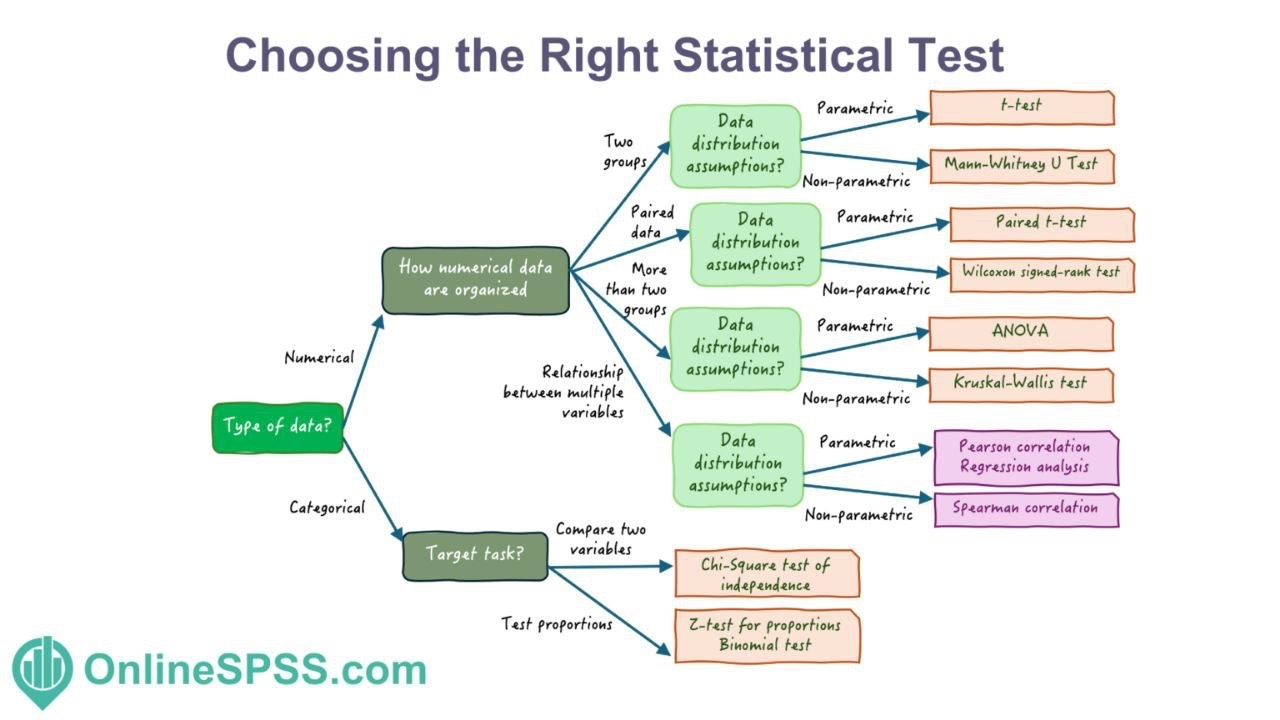

Посмотрим, какой минимальный эффект мы сможем увидеть на нынешних данных

In [ ]:
n_control = df1[df1['group'] == 'control'].shape[0]
n_treatment = df1[df1['group'] == 'treatment'].shape[0]
p_control = df1['converted'].mean()
alpha=0.05
power=0.8

mde = (norm.ppf(1 - alpha/2) + norm.ppf(power)) * np.sqrt(p_control * (1 - p_control) * (1/n_control + 1/n_treatment))
print(f"MDE: {mde*100:.6f}")

MDE: 0.339388


Проведем z-тест

In [ ]:
z_stat, p_val = proportions_ztest(
    np.array([df1[df1['group'] == 'control']['converted'].sum(), df1[df1['group'] == 'treatment']['converted'].sum()]),
    np.array([df1[df1['group'] == 'control'].shape[0], df1[df1['group'] == 'treatment'].shape[0]]), alternative='smaller')

print(f"Конверсия в контрольной группе: {(df1[df1['group'] == 'control']['converted'].mean()):.6f}")
print(f"Конверсия в экспериментальной группе: {(df1[df1['group'] == 'treatment']['converted'].mean()):.6f}")
print(f"P-value: {p_val:.6f}")

Конверсия в контрольной группе: 0.120173
Конверсия в экспериментальной группе: 0.118726
P-value: 0.883856


Как можем заметить, конверсии статистически не отличаются, то есть внедрять новую страницу бессмысленно, нулевая гипотеза не отвергается

Будет полезно посмотреть, различаются ли как-то конверсии в динамике по дням - это очень просто сделать, ведь тест всего шел 22 дня

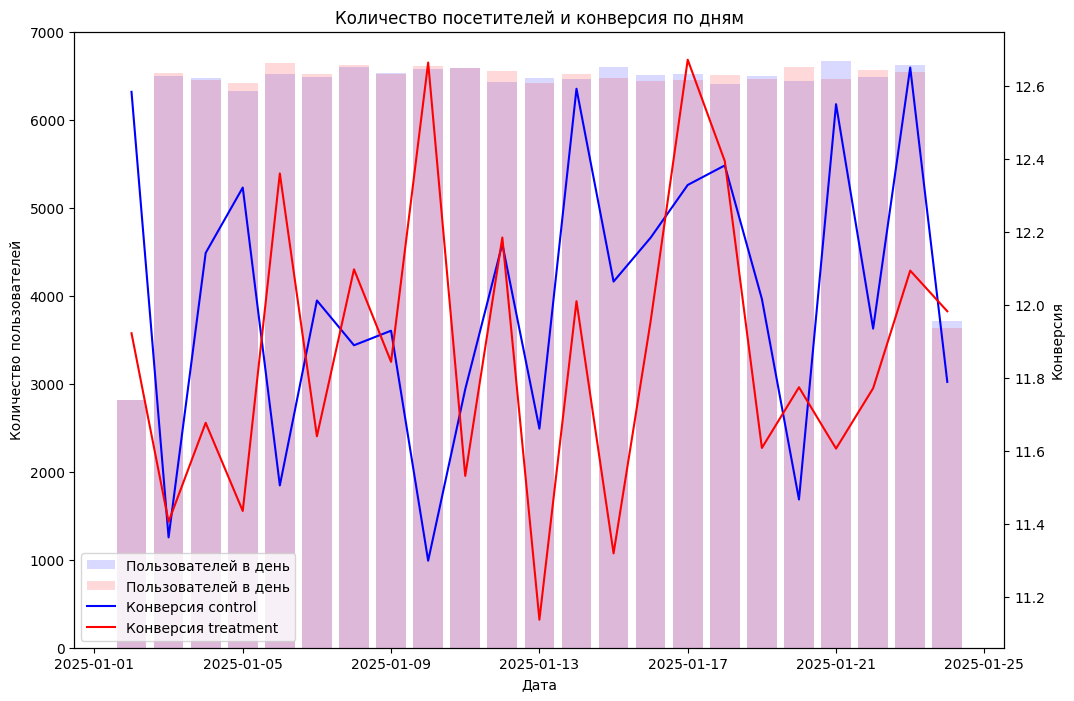

In [ ]:
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df1['date'] = df1['timestamp'].dt.date
daily_users = df1.groupby('date')['user_id'].count()

daily_control = df1[df1['group'] == 'control'].groupby('date')['converted'].mean()
daily_treatment = df1[df1['group'] != 'control'].groupby('date')['converted'].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(df1[df1['group'] == 'control'].groupby('date')['user_id'].count().index,
        df1[df1['group'] == 'control'].groupby('date')['user_id'].count().values, color='blue', alpha=0.15, label='Пользователей в день')
ax1.bar(df1[df1['group'] == 'treatment'].groupby('date')['user_id'].count().index,
        df1[df1['group'] == 'treatment'].groupby('date')['user_id'].count().values, color='red', alpha=0.15, label='Пользователей в день')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Дата')

ax2 = ax1.twinx()
ax2.plot(daily_control.index, daily_control.values * 100, 'b-', label='Конверсия control')
ax2.plot(daily_treatment.index, daily_treatment.values * 100, 'r-', label='Конверсия treatment')
ax2.set_ylabel('Конверсия')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.title('Количество посетителей и конверсия по дням')
plt.show()

Видим что кол-во пользователей было в целом стабильным во все время проведения теста - около 6500 пользователей в день, также как и конверсии по дням изменяются лишь с 11.2% до 12.6%

Сагрегируем по неделям

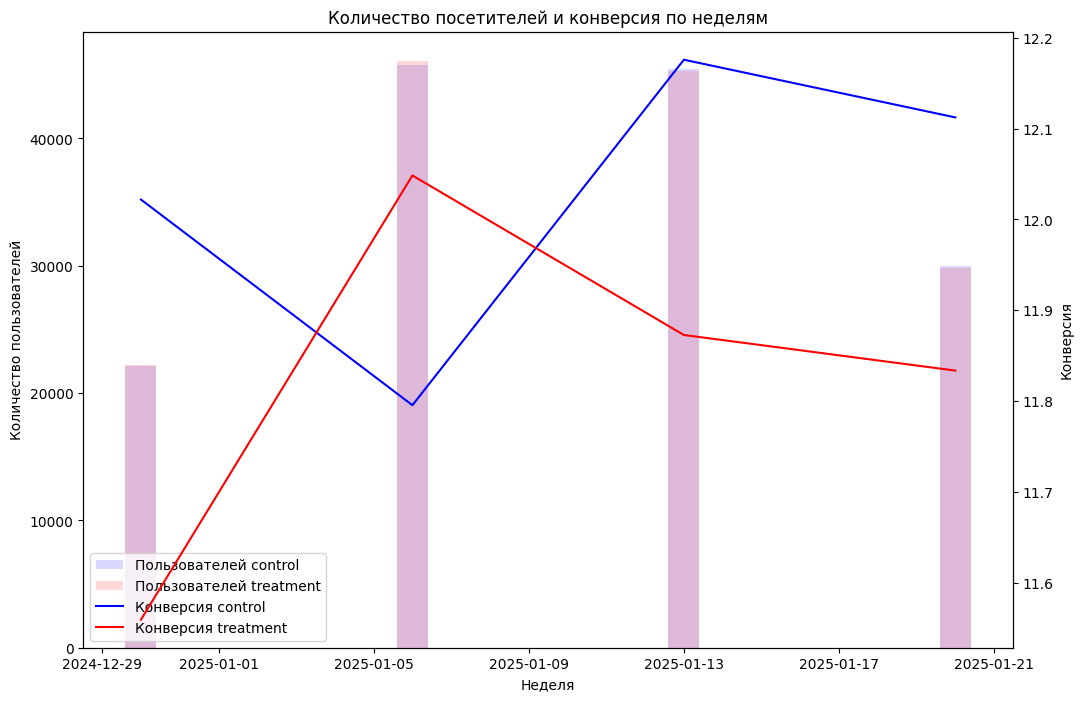

In [ ]:
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df1['week'] = df1['timestamp'].dt.to_period('W').dt.start_time.dt.date
weekly_control = df1[df1['group'] == 'control'].groupby('week')['converted'].mean()
weekly_treatment = df1[df1['group'] == 'treatment'].groupby('week')['converted'].mean()
users_control = df1[df1['group'] == 'control'].groupby('week')['user_id'].count()
users_treatment = df1[df1['group'] == 'treatment'].groupby('week')['user_id'].count()

fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.bar(users_control.index, users_control.values, color='blue', alpha=0.15, label='Пользователей control')
ax1.bar(users_treatment.index, users_treatment.values, color='red', alpha=0.15, label='Пользователей treatment')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Неделя')

ax2 = ax1.twinx()
ax2.plot(weekly_control.index, weekly_control.values * 100, 'b-', label='Конверсия control')
ax2.plot(weekly_treatment.index, weekly_treatment.values * 100, 'r-', label='Конверсия treatment')
ax2.set_ylabel('Конверсия')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('Количество посетителей и конверсия по неделям')
plt.show()


По неделям тоже нельзя выделить каких-то значительных изменений

# Включим дублирующихся пользователей

Если человек видел сайт больше 1 раза, он видел его ровно два раза. Логично, что на второе взаимодействие повлияло первое взаимодействие. Поэтому давайте смотреть только на первое взаимодействие пользователей с сайтом

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df2 = df.sort_values('timestamp').drop_duplicates(subset='user_id', keep='first')
df.shape[0], df2.shape[0]

(294478, 290584)

In [ ]:
df2.groupby(['group', 'landing_page', 'converted']).size()

group      landing_page  converted
control    new_page      0               854
                         1               121
           old_page      0            126944
                         1             17375
treatment  new_page      0            127186
                         1             17130
           old_page      0               839
                         1               135
dtype: int64

Как можем заметить, что-то пошло не так. Наша сплит система сломалась (учитывая пункт, где мы исключили пользователей с 2 строками, она ломается ровно в них), так как в одной группе по два типа страниц. Мы не можем просто закинуть всех пользователей с old_page в control (для new_page в treatment), так как тогда мы можем потерять однородность данных. Поэтому просто удалим некорректных пользователей

In [ ]:
df2 = df2[((df2['group'] == 'control') & (df2['landing_page'] == 'old_page')) |
 ((df2['group'] != 'control') & (df2['landing_page'] != 'old_page'))]

In [ ]:
df2.groupby(['group', 'landing_page', 'converted']).size()

group      landing_page  converted
control    old_page      0            126944
                         1             17375
treatment  new_page      0            127186
                         1             17130
dtype: int64

Победа, оно починилось!

Проверим, что данные однородные

In [ ]:
df2[df2['group'] == 'control'].shape[0], df2[df2['group'] != 'control'].shape[0]

(144319, 144316)

In [ ]:
(df2[df2['group'] != 'control'].shape[0] - df2[df2['group'] == 'control'].shape[0]) / df2[df2['group'] == 'control'].shape[0] * 100

-0.0020787283725635574

In [ ]:
chi2, p_value = chisquare(f_obs=df2['group'].value_counts(),
                          f_exp=[df2['group'].value_counts().sum() / 2, df2['group'].value_counts().sum() / 2])

print(f"P-value = {p_value:.6f}")

P-value = 0.995545


Различие в размерах выборок 0.002%, различия статистически не значимы

В качестве метрики возьмем долю зарегистрировавшихся пользователей.

Сформулируем нулевую и альтернативные гипотезы:
*   H0: доля зарегистрировавшихся пользователей в экспериментальной группе не выше, чем в контрольной
*   H1: доля зарегистрировавшихся пользователей в экспериментальной группе выше, чем в контрольной

Так как мы рассматриваем доли, в качестве статистического теста выберем Z-тест. Проверим, что можем его проводить:


*   У нас категориальные данные (пользователь зарегистрировался или нет)
*   Данных достаточно много, чтобы применять ЦПТ (их почти 300 тысяч)
*   Мы рассматриваем пропорции
*   Данные в группах независимы



Посмотрим, какой минимальный эффект мы сможем увидеть на нынешних данных

In [ ]:
n_control = df2[df2['group'] == 'control'].shape[0]
n_treatment = df2[df2['group'] == 'treatment'].shape[0]
p_control = df2['converted'].mean()
alpha=0.05
power=0.8

mde = (norm.ppf(1 - alpha/2) + norm.ppf(power)) * np.sqrt(p_control * (1 - p_control) * (1/n_control + 1/n_treatment))
print(f"MDE: {mde*100:.6f}")

MDE: 0.338360


Проведем z-тест

In [ ]:
z_stat, p_val = proportions_ztest(
    np.array([df2[df2['group'] == 'control']['converted'].sum(), df2[df2['group'] == 'treatment']['converted'].sum()]),
    np.array([df2[df2['group'] == 'control'].shape[0], df2[df2['group'] == 'treatment'].shape[0]]), alternative='smaller')

print(f"Конверсия в контрольной группе: {(df2[df2['group'] == 'control']['converted'].mean()):.6f}")
print(f"Конверсия в экспериментальной группе: {(df2[df2['group'] == 'treatment']['converted'].mean()):.6f}")
print(f"P-value: {p_val:.6f}")

Конверсия в контрольной группе: 0.120393
Конверсия в экспериментальной группе: 0.118698
P-value: 0.919777


**Вывод:** мы проверили изменение конверсий в контрольной и экспериментальной группе, учитывая и не учитывая некорректно полученных пользователей. Данные не показали никакой статистической значимости, советуем продукту проверить сплит систему и пока не внедрять новую страницу сайта

Как можем заметить, конверсии статистически не отличаются, то есть внедрять новую страницу бессмысленно, нулевая гипотеза не отвергается

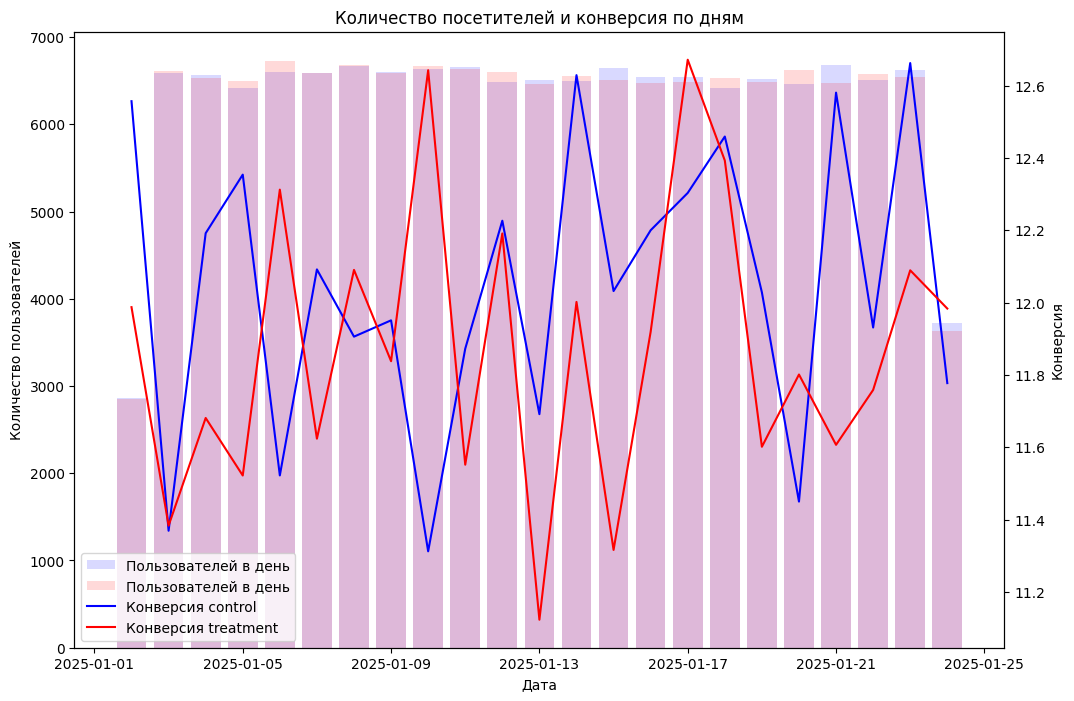

In [ ]:
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2['date'] = df2['timestamp'].dt.date
daily_control = df2[df2['group'] == 'control'].groupby('date')['converted'].mean()
daily_treatment = df2[df2['group'] != 'control'].groupby('date')['converted'].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(df2[df2['group'] == 'control'].groupby('date')['user_id'].count().index,
        df2[df2['group'] == 'control'].groupby('date')['user_id'].count().values, color='blue', alpha=0.15, label='Пользователей в день')
ax1.bar(df2[df2['group'] == 'treatment'].groupby('date')['user_id'].count().index,
        df2[df2['group'] == 'treatment'].groupby('date')['user_id'].count().values, color='red', alpha=0.15, label='Пользователей в день')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Дата')

ax2 = ax1.twinx()
ax2.plot(daily_control.index, daily_control.values * 100, 'b-', label='Конверсия control')
ax2.plot(daily_treatment.index, daily_treatment.values * 100, 'r-', label='Конверсия treatment')
ax2.set_ylabel('Конверсия')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.title('Количество посетителей и конверсия по дням')
plt.show()

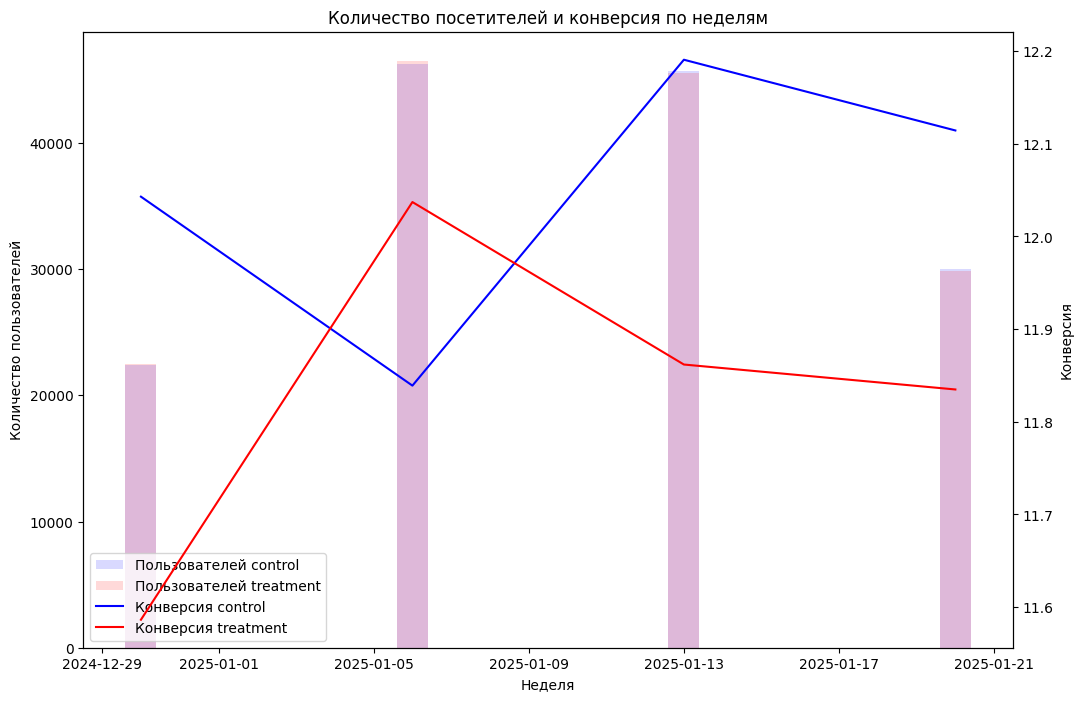

In [ ]:
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2['week'] = df2['timestamp'].dt.to_period('W').dt.start_time.dt.date
weekly_control = df2[df2['group'] == 'control'].groupby('week')['converted'].mean()
weekly_treatment = df2[df2['group'] == 'treatment'].groupby('week')['converted'].mean()
users_control = df2[df2['group'] == 'control'].groupby('week')['user_id'].count()
users_treatment = df2[df2['group'] == 'treatment'].groupby('week')['user_id'].count()

fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.bar(users_control.index, users_control.values, color='blue', alpha=0.15, label='Пользователей control')
ax1.bar(users_treatment.index, users_treatment.values, color='red', alpha=0.15, label='Пользователей treatment')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('Неделя')

ax2 = ax1.twinx()
ax2.plot(weekly_control.index, weekly_control.values * 100, 'b-', label='Конверсия control')
ax2.plot(weekly_treatment.index, weekly_treatment.values * 100, 'r-', label='Конверсия treatment')
ax2.set_ylabel('Конверсия')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('Количество посетителей и конверсия по неделям')
plt.show()

# Размышления о дублирующихся данных

In [ ]:
merged = pd.merge(df, df, on='user_id', suffixes=('_1', '_2'))
merged = merged[merged['timestamp_1'] < merged['timestamp_2']]
merged.groupby(['group_1', 'landing_page_1', 'converted_1', 'group_2', 'landing_page_2', 'converted_2']).size()

group_1    landing_page_1  converted_1  group_2    landing_page_2  converted_2
control    new_page        0            control    old_page        0              373
                                                                   1               44
                                        treatment  new_page        0              386
                                                                   1               51
                           1            control    old_page        0               58
                                                                   1                7
                                        treatment  new_page        0               50
                                                                   1                6
           old_page        0            control    new_page        0              386
                                                                   1               50
                                        treatment  old_page        0              389
                                                                   1               46
                           1            control    new_page        0               77
                                                                   1               12
                                        treatment  old_page        0               61
                                                                   1                5
treatment  new_page        0            control    new_page        0              332
                                                                   1               47
                                        treatment  new_page        0                1
                                                   old_page        0              377
                                                                   1               57
                           1            control    new_page        0               45
                                                                   1                4
                                        treatment  old_page        0               49
                                                                   1                7
           old_page        0            control    old_page        0              351
                                                                   1               55
                                        treatment  new_page        0              371
                                                                   1               62
                           1            control    old_page        0               59
                                                                   1                8
                                        treatment  new_page        0               53
                                                                   1               15
dtype: int64

Заметим, что если в одну сессию пользователь распределился некорректно, то в другой он распределился корректно. То есть если пользователь сначала попал в группу control с old_page, то в следующий раз он попадет или в ту же группу, но с другой страницей, или в ту же страницу, но в другой группе. В обратную сторону работает так же (когда сначала попадает неправильно, во вторую итерацию правильно)

Заметим, что в этой закономерности есть один выброс, который все два раза был на новой странице в группе treatment. С ним ничего интересного не происходило, он в оба раза не зарегистрировался, учитывая, что это 1 человек из 3894 дублирующихся, наша гипотеза с закономерностью работает :)

In [ ]:
merged.shape

(3894, 9)

In [ ]:
lower, upper = proportion_confint(3893, 3894, method='wilson')
print(f"Доля: {3893/3894:.6f}")
print(f"95% ДИ: [{lower:.6f}, {upper:.6f}]")

Доля: 0.999743
95% ДИ: [0.998547, 0.999955]


In [ ]:
merged[(merged['group_1'] == 'treatment') & (merged['group_2'] == 'treatment') & (merged['landing_page_1'] == 'new_page') &
       (merged['landing_page_2'] == 'new_page')]

,user_id,timestamp_1,group_1,landing_page_1,converted_1,timestamp_2,group_2,landing_page_2,converted_2
1947,773192,2025-01-09 05:37:58.781806,treatment,new_page,0,2025-01-14 02:55:59.590927,treatment,new_page,0


# Доп штуки

In [ ]:
def bootstrap_ab_test(df, n=5000):
    ctrl = df[df['group'] == 'control']['converted'].values
    treat = df[df['group'] == 'treatment']['converted'].values

    diffs = np.array([np.random.choice(treat, len(treat), replace=True).mean() - np.random.choice(ctrl, len(ctrl), replace=True).mean() for i in range(n)])

    lower, upper = np.percentile(diffs, [2.5, 97.5])
    return diffs, lower, upper

In [ ]:
ctrl = df1[df1['group'] == 'control']['converted']
treat = df1[df1['group'] == 'treatment']['converted']
diffs, lower, upper = bootstrap_ab_test(df1)

print('Control:', round(ctrl.mean() * 100, 2), '%')
print('Treatment:', round(treat.mean() * 100, 2), '%')
print('95% ДИ:', round(lower * 100, 2), '-', round(upper * 100, 2), '%')

Control: 12.02 %
Treatment: 11.87 %
95% ДИ: -0.38 - 0.09 %


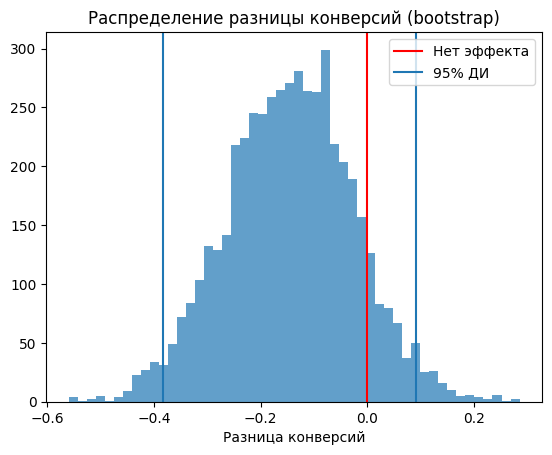

In [ ]:
plt.hist(diffs * 100, bins=50, alpha=0.7)
plt.axvline(0, label='Нет эффекта', color='red')
plt.axvline(lower * 100, label='95% ДИ')
plt.axvline(upper * 100)
plt.xlabel('Разница конверсий')
plt.title('Распределение разницы конверсий (bootstrap)')
plt.legend()
plt.show()

In [ ]:
z_stat, p_val = proportions_ztest([ctrl.sum(), treat.sum()], [len(ctrl), len(treat)], alternative='two-sided')
print('Z-тест p-value:', round(p_val, 4))

Z-тест p-value: 0.2323


Оба теста показывают отсутствие эффекта

In [ ]:
ctrl = df2[df2['group'] == 'control']['converted']
treat = df2[df2['group'] == 'treatment']['converted']
diffs, lower, upper = bootstrap_ab_test(df2)

print('Control:', round(ctrl.mean() * 100, 2), '%')
print('Treatment:', round(treat.mean() * 100, 2), '%')
print('95% ДИ:', round(lower * 100, 2), '-', round(upper * 100, 2), '%')

Control: 12.04 %
Treatment: 11.87 %
95% ДИ: -0.4 - 0.07 %


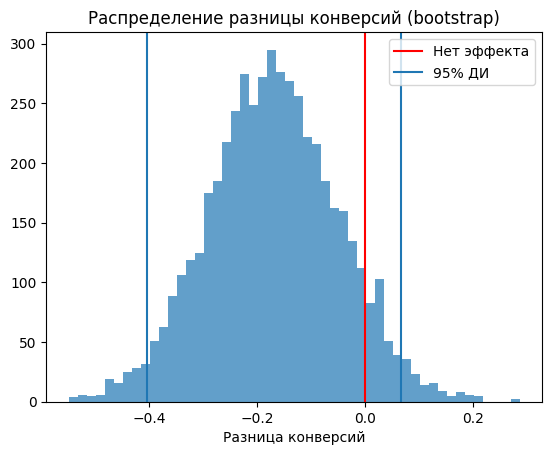

In [ ]:
plt.hist(diffs * 100, bins=50, alpha=0.7)
plt.axvline(0, label='Нет эффекта', color='red')
plt.axvline(lower * 100, label='95% ДИ')
plt.axvline(upper * 100)
plt.xlabel('Разница конверсий')
plt.title('Распределение разницы конверсий (bootstrap)')
plt.legend()
plt.show()

In [ ]:
z_stat, p_val = proportions_ztest([ctrl.sum(), treat.sum()], [len(ctrl), len(treat)], alternative='two-sided')
print('Z-тест p-value:', round(p_val, 4))

Z-тест p-value: 0.1604


Оба теста показывают отсутствие эффекта

Давайте посмотрим, зависит ли доля ошибок от дня или времени суток

In [ ]:
df3 = df.copy()
df3['timestamp'] = pd.to_datetime(df3['timestamp'])
df3['date'] = df3['timestamp'].dt.date
df3['is_good'] = np.where(
((df3['landing_page'] == 'old_page') & (df3['group'] == 'control')) |
((df3['landing_page'] == 'new_page') & (df3['group'] == 'treatment')),
1, 0
)

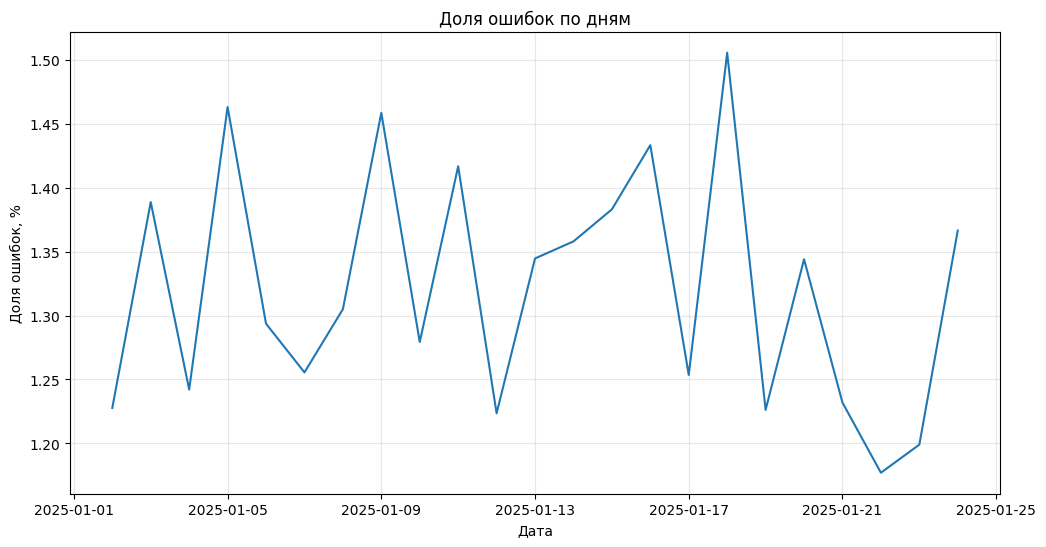

In [ ]:
df3_days = ((df3[df3['is_good'] == 0]['date'].value_counts() / df3['date'].value_counts()).fillna(0) * 100).sort_index()

plt.figure(figsize=(12, 6))
plt.plot(df3_days.index, df3_days.values)
plt.title('Доля ошибок по дням')
plt.xlabel('Дата')
plt.ylabel('Доля ошибок, %')
plt.grid(True, alpha=0.3)
plt.show()

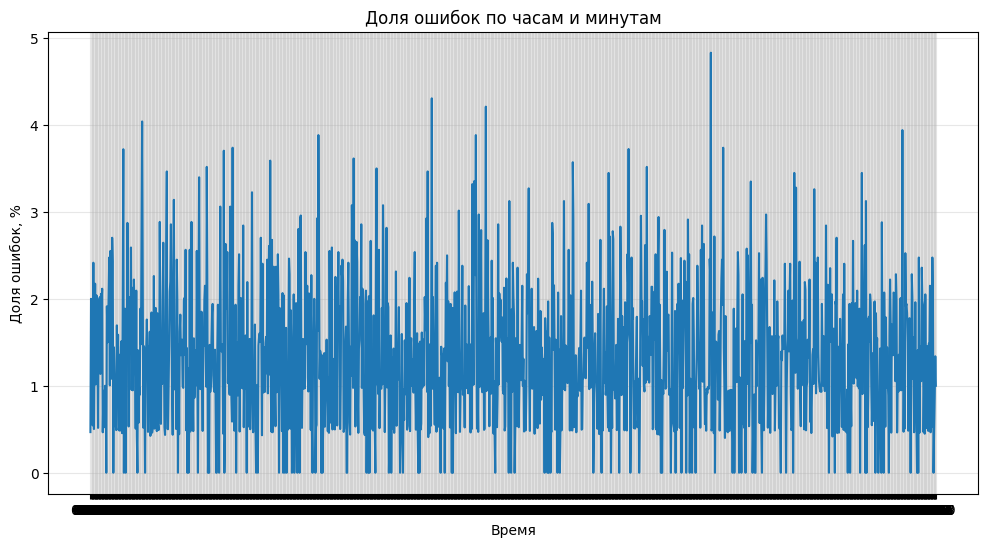

In [ ]:
df3['hour_minute'] = df3['timestamp'].dt.strftime('%H:%M')
df3_days = ((df3[df3['is_good'] == 0]['hour_minute'].value_counts() / df3['hour_minute'].value_counts()).fillna(0) * 100).sort_index()

plt.figure(figsize=(12, 6))
plt.plot(df3_days.index, df3_days.values)
plt.title('Доля ошибок по часам и минутам')
plt.xlabel('Время')
plt.ylabel('Доля ошибок, %')
plt.grid(True, alpha=0.3)
plt.show()

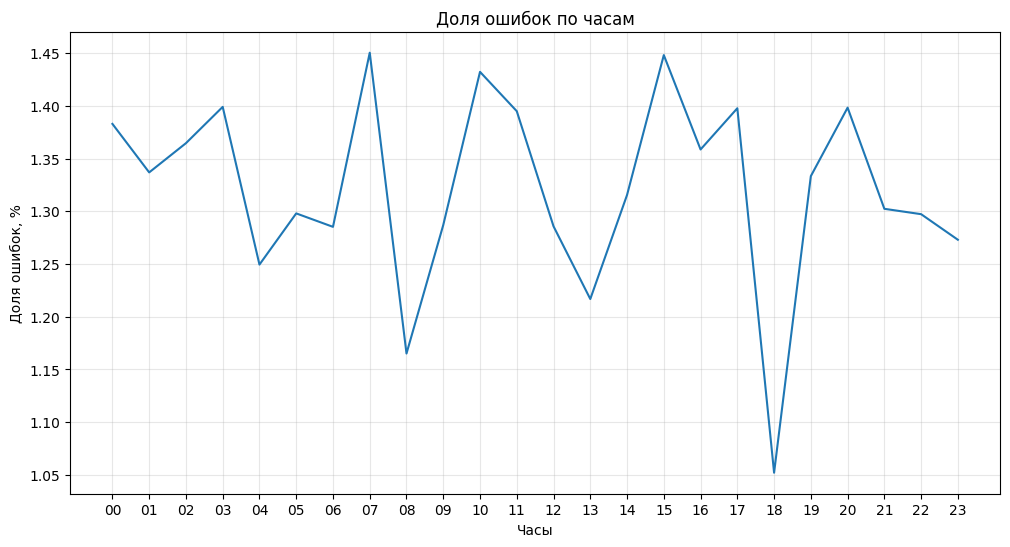

In [ ]:
df3['hour'] = df3['timestamp'].dt.strftime('%H')
df3_days = ((df3[df3['is_good'] == 0]['hour'].value_counts() / df3['hour'].value_counts()).fillna(0) * 100).sort_index()

plt.figure(figsize=(12, 6))
plt.plot(df3_days.index, df3_days.values)
plt.title('Доля ошибок по часам')
plt.xlabel('Часы')
plt.ylabel('Доля ошибок, %')
plt.grid(True, alpha=0.3)
plt.show()

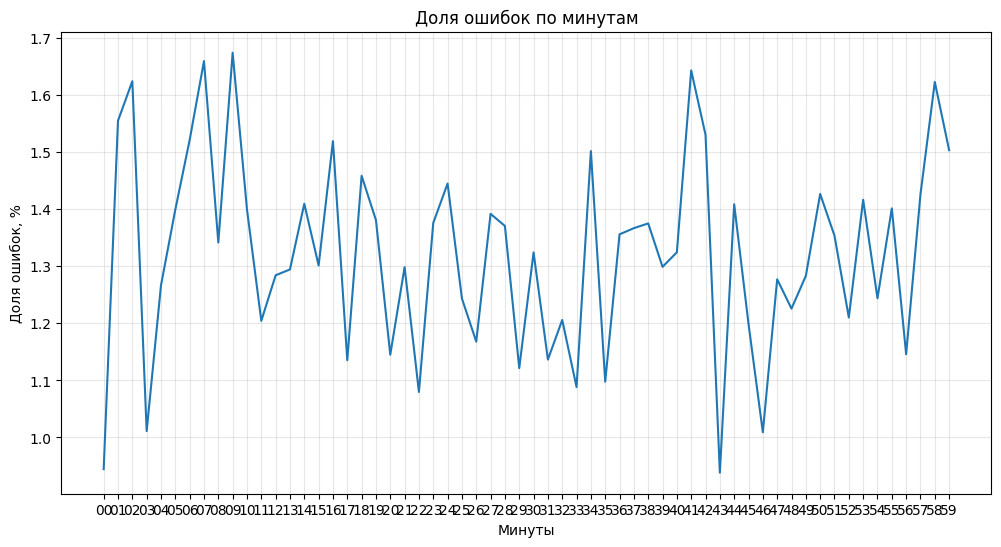

In [ ]:
df3['minute'] = df3['timestamp'].dt.strftime('%M')
df3_days = ((df3[df3['is_good'] == 0]['minute'].value_counts() / df3['minute'].value_counts()).fillna(0) * 100).sort_index()

plt.figure(figsize=(12, 6))
plt.plot(df3_days.index, df3_days.values)
plt.title('Доля ошибок по минутам')
plt.xlabel('Минуты')
plt.ylabel('Доля ошибок, %')
plt.grid(True, alpha=0.3)
plt.show()

Давайте посмотрим, зависит ли конверсия от времени суток

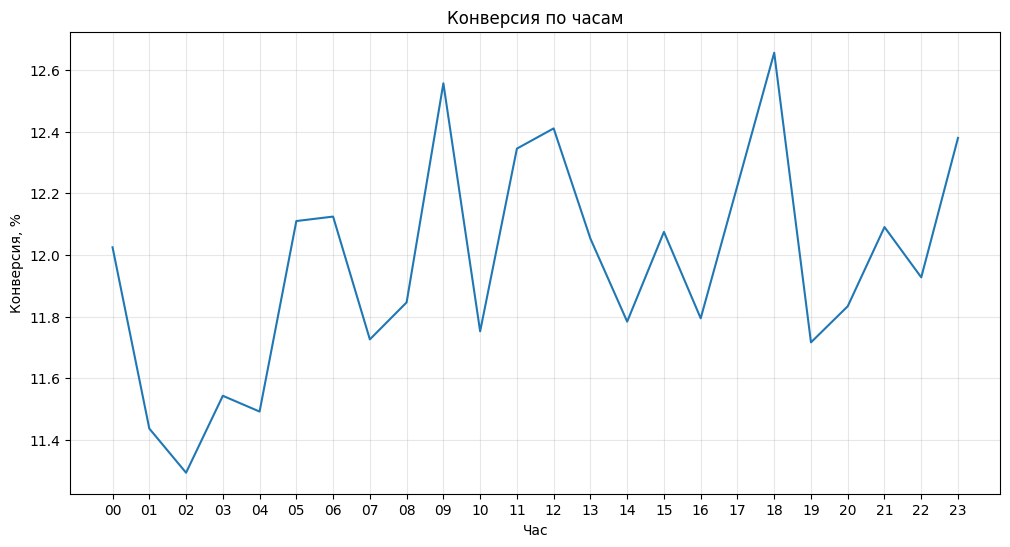

In [ ]:
df3_days = ((df3[df3['converted'] == 1]['hour'].value_counts() / df3['hour'].value_counts()).fillna(0) * 100).sort_index()

plt.figure(figsize=(12, 6))
plt.plot(df3_days.index, df3_days.values)
plt.title('Конверсия по часам')
plt.xlabel('Час')
plt.ylabel('Конверсия, %')
plt.grid(True, alpha=0.3)
plt.show()